# Apply crop bbox offset to Ji/MVN graph

This notebook takes a Ji/MVN graph stored in **local crop coordinates** and moves it into **global whole-brain coordinates** using the crop bounding-box origin stored in the original `.mat` file.

Use this notebook only for **crop/subvolume graphs**. For a whole-brain graph that is already in global coordinates, do **not** apply this offset.

Main idea:

```python
coords_global = coords_local_scaled + bbox_offset_xyz
```

Important: the input `.pkl` is already scaled by `1.051`. The `bbox_mmll[:3]` value is an **offset/origin**, not local graph geometry, so the bbox offset must **not** be multiplied by `1.051`.


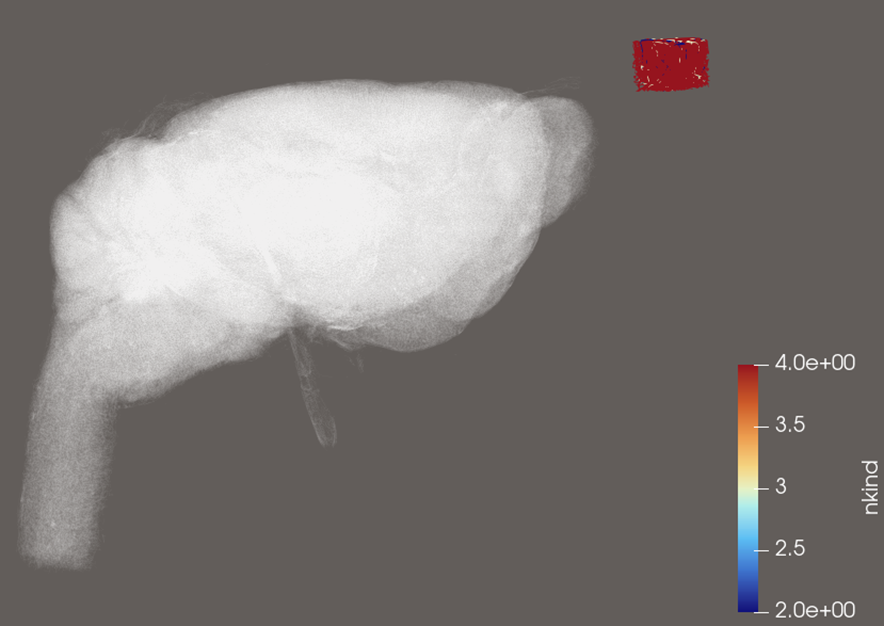

In [7]:
import pickle
import numpy as np
import scipy.io
from pathlib import Path

print('Imports loaded')

Imports loaded


## 1. Define paths

Update these paths if needed.

In [8]:
mat_path = Path(r"C:\Users\Ana\Documents\ARTORG\XiangJi\files\ML20180815_240_c5o1_578.mat")

# Input graph: already converted from .mat to .pkl and scaled by 1.051, but still in local crop coordinates
pkl_in = Path(r"C:\Users\Ana\Documents\ARTORG\XiangJi\files\ML20180815_240_c5o1_578_mvn1_scaled.pkl")

# Shrinkage correction used in the Ji graph conversion
SHRINKAGE_CORRECTION = 1.051

print('MAT exists:', mat_path.exists(), mat_path)
print('PKL exists:', pkl_in.exists(), pkl_in)

MAT exists: True C:\Users\Ana\Documents\ARTORG\XiangJi\files\ML20180815_240_c5o1_578.mat
PKL exists: True C:\Users\Ana\Documents\ARTORG\XiangJi\files\ML20180815_240_c5o1_578_mvn1_scaled.pkl


## 2. Load `.mat` and `.pkl`

In [9]:
mat = scipy.io.loadmat(
    mat_path,
    struct_as_record=False,
    squeeze_me=True,
)

with open(pkl_in, 'rb') as f:
    G = pickle.load(f)

print(G.summary())
print('Graph attrs:', G.attributes())
print('Vertex attrs:', G.vs.attributes())
print('Edge attrs:', G.es.attributes())

IGRAPH U--- 11732 16640 -- 
+ attr: mask_size (g), mat_loader (g), coords (v), diameter (v), index (v), connectivity (e), diameter (e), diameters (e), length (e), lengths2 (e), nkind (e), points (e)
Graph attrs: ['mask_size', 'mat_loader']
Vertex attrs: ['coords', 'diameter', 'index']
Edge attrs: ['points', 'lengths2', 'length', 'diameters', 'diameter', 'nkind', 'connectivity']


## 3. Inspect bbox information in the `.mat`

`bbox_mmll[:3]` contains the global crop origin in MATLAB order:

```text
(Y, X, Z)
```

The graph coordinates are handled as:

```text
(X, Y, Z)
```

So the offset must be reordered before applying it:

```python
offset_xyz = offset_yxz[[1, 0, 2]]
```

Do **not** multiply this offset by `1.051`; it is a translation/origin, not a geometric length from the local graph.


In [10]:
info = mat['info']

bbox_mmll = np.asarray(info.bbox_mmll).ravel().astype(float)
bbox_mmxx = np.asarray(info.bbox_mmxx).ravel().astype(float)

print('bbox_mmll:', bbox_mmll)
print('bbox_mmxx:', bbox_mmxx)

# bbox_mmll is in MATLAB order: (Y, X, Z, sizeY, sizeX, sizeZ)
offset_yxz = bbox_mmll[:3]
offset_xyz = offset_yxz[[1, 0, 2]]

bbox_size_yxz = bbox_mmll[3:6]
bbox_size_xyz = bbox_size_yxz[[1, 0, 2]]

# bbox_mmxx[3:6] is the max corner in the same MATLAB order, so reorder too
bbox_max_yxz = bbox_mmxx[3:6]
bbox_max_xyz = bbox_max_yxz[[1, 0, 2]]

print('Parsed bbox:')
print('origin yxz:', offset_yxz)
print('origin xyz:', offset_xyz)
print('size yxz:  ', bbox_size_yxz)
print('size xyz:  ', bbox_size_xyz)
print('max yxz:   ', bbox_max_yxz)
print('max xyz:   ', bbox_max_xyz)
print('max-origin xyz:', bbox_max_xyz - offset_xyz)

if hasattr(info, 'dataset_size'):
    dataset_size_yxz = np.asarray(info.dataset_size).ravel().astype(float)
    dataset_size_xyz = dataset_size_yxz[[1, 0, 2]]
    print('whole-brain dataset size:')
    print('dataset_size yxz:', dataset_size_yxz)
    print('dataset_size xyz:', dataset_size_xyz)
    print('Expected whole-brain bounds in graph XYZ order:')
    print('X: [0,', dataset_size_xyz[0], ']')
    print('Y: [0,', dataset_size_xyz[1], ']')
    print('Z: [0,', dataset_size_xyz[2], ']')


bbox_mmll: [ 833. 2497. 6657. 1072. 1072. 1072.]
bbox_mmxx: [ 833. 2497. 6657. 1904. 3568. 7728.]
Parsed bbox:
origin yxz: [ 833. 2497. 6657.]
origin xyz: [2497.  833. 6657.]
size yxz:   [1072. 1072. 1072.]
size xyz:   [1072. 1072. 1072.]
max yxz:    [1904. 3568. 7728.]
max xyz:    [3568. 1904. 7728.]
max-origin xyz: [1071. 1071. 1071.]
whole-brain dataset size:
dataset_size yxz: [11264. 10368. 13312.]
dataset_size xyz: [10368. 11264. 13312.]
Expected whole-brain bounds in graph XYZ order:
X: [0, 10368.0 ]
Y: [0, 11264.0 ]
Z: [0, 13312.0 ]


## 4. Helper functions

In [11]:
def graph_bounds(G):
    """Return node and edge-point bounds."""
    coords = np.asarray(G.vs['coords'], dtype=float)
    node_min = coords.min(axis=0)
    node_max = coords.max(axis=0)

    pmin = np.array([np.inf, np.inf, np.inf])
    pmax = np.array([-np.inf, -np.inf, -np.inf])

    if 'points' in G.es.attributes():
        for pts in G.es['points']:
            pts = np.asarray(pts, dtype=float)
            if pts.size == 0:
                continue
            pmin = np.minimum(pmin, pts.min(axis=0))
            pmax = np.maximum(pmax, pts.max(axis=0))

    return node_min, node_max, pmin, pmax


def print_graph_bounds(G, name='G'):
    node_min, node_max, pmin, pmax = graph_bounds(G)

    print(f'=== {name}: NODE COORDS ===')
    print('min:   ', node_min)
    print('max:   ', node_max)
    print('extent:', node_max - node_min)
    print('center:', (node_max + node_min) / 2)

    print(f'=== {name}: EDGE POINTS ===')
    print('min:   ', pmin)
    print('max:   ', pmax)
    print('extent:', pmax - pmin)
    print('center:', (pmax + pmin) / 2)


def get_bbox_offset_xyz(mat):
    """
    Extract crop/global offset from bbox_mmll.

    bbox_mmll[:3] is in MATLAB order (Y, X, Z).
    Return offset in graph order (X, Y, Z).

    This offset is a translation/origin, not graph geometry,
    so it must NOT be scaled by 1.051.
    """
    info = mat['info']
    bbox = np.asarray(info.bbox_mmll).ravel().astype(float)

    offset_yxz = bbox[:3]
    offset_xyz = offset_yxz[[1, 0, 2]]

    print('offset (Y,X,Z):', offset_yxz)
    print('offset (X,Y,Z):', offset_xyz)

    return offset_xyz


def apply_offset_to_graph(G, offset_xyz, offset_label='bbox_mmll'):
    """
    Return a copy of G translated by offset_xyz.

    Translation affects coords, node_points and edge points.
    It does not change lengths, lengths2 or diameters.
    """
    G2 = G.copy()
    offset_xyz = np.asarray(offset_xyz, dtype=float)

    if 'coords' in G2.vs.attributes():
        G2.vs['coords'] = [
            tuple((np.asarray(c, dtype=float) + offset_xyz).tolist())
            for c in G2.vs['coords']
        ]

    if 'node_points' in G2.vs.attributes():
        G2.vs['node_points'] = [
            (np.asarray(p, dtype=float) + offset_xyz).tolist()
            for p in G2.vs['node_points']
        ]

    if 'points' in G2.es.attributes():
        G2.es['points'] = [
            (np.asarray(p, dtype=float) + offset_xyz).tolist()
            for p in G2.es['points']
        ]

    G2['coord_space'] = 'global_whole_brain'
    G2['crop_offset_xyz'] = offset_xyz.tolist()
    G2['offset_source'] = offset_label

    return G2


def apply_global_offset(G, mat):
    """
    Shift graph coordinates to global brain space in place.

    bbox_mmll[:3] is the MVN origin in MATLAB (Y, X, Z) order,
    then reordered to graph (X, Y, Z) order.

    The offset is NOT scaled by 1.051 because it is a translation/origin,
    not local graph geometry.
    """
    offset_xyz = get_bbox_offset_xyz(mat)

    if 'coords' in G.vs.attributes():
        G.vs['coords'] = [
            tuple((np.asarray(c, dtype=float) + offset_xyz).tolist())
            for c in G.vs['coords']
        ]

    if 'node_points' in G.vs.attributes():
        G.vs['node_points'] = [
            (np.asarray(p, dtype=float) + offset_xyz).tolist()
            for p in G.vs['node_points']
        ]

    if 'points' in G.es.attributes():
        G.es['points'] = [
            (np.asarray(p, dtype=float) + offset_xyz).tolist()
            for p in G.es['points']
        ]

    G['coord_space'] = 'global_whole_brain'
    G['crop_offset_xyz'] = offset_xyz.tolist()
    G['offset_source'] = 'mat.info.bbox_mmll[:3] yxz->xyz, unscaled'


def check_bounds_inside_dataset(G, dataset_size_xyz, name='G'):
    node_min, node_max, pmin, pmax = graph_bounds(G)
    dataset_size_xyz = np.asarray(dataset_size_xyz, dtype=float)

    print(f'=== {name}: INSIDE WHOLE-BRAIN DATASET CHECK ===')
    print('dataset size xyz:', dataset_size_xyz)
    print('edge min >= 0?', np.all(pmin >= 0))
    print('edge max <= dataset_size?', np.all(pmax <= dataset_size_xyz))
    print('node min >= 0?', np.all(node_min >= 0))
    print('node max <= dataset_size?', np.all(node_max <= dataset_size_xyz))


## 5. Bounds before offset

This should show the crop close to `[0, 0, 0]`, because the graph is still in local crop coordinates.

In [12]:
print_graph_bounds(G, 'BEFORE OFFSET / LOCAL CROP')

=== BEFORE OFFSET / LOCAL CROP: NODE COORDS ===
min:    [0.    1.051 0.   ]
max:    [1125.621 1125.621 1124.57 ]
extent: [1125.621 1124.57  1124.57 ]
center: [562.8105 563.336  562.285 ]
=== BEFORE OFFSET / LOCAL CROP: EDGE POINTS ===
min:    [0. 0. 0.]
max:    [1125.621 1125.621 1125.621]
extent: [1125.621 1125.621 1125.621]
center: [562.8105 562.8105 562.8105]


## 6. Offset


In [13]:
# Offset from bbox, reordered from MATLAB YXZ to graph XYZ.
# Do NOT multiply this by 1.051.
offset_xyz = get_bbox_offset_xyz(mat)
print('offset xyz used for translation:', offset_xyz)


offset (Y,X,Z): [ 833. 2497. 6657.]
offset (X,Y,Z): [2497.  833. 6657.]
offset xyz used for translation: [2497.  833. 6657.]


## 7. Apply offsets and compare bounds

In [14]:
G_global = apply_offset_to_graph(
    G,
    offset_xyz,
    offset_label='mat.info.bbox_mmll[:3] yxz->xyz, unscaled',
)

print_graph_bounds(G_global, 'AFTER BBOX OFFSET / GLOBAL')

if hasattr(info, 'dataset_size'):
    check_bounds_inside_dataset(G_global, dataset_size_xyz, 'AFTER BBOX OFFSET / GLOBAL')


=== AFTER BBOX OFFSET / GLOBAL: NODE COORDS ===
min:    [2497.     834.051 6657.   ]
max:    [3622.621 1958.621 7781.57 ]
extent: [1125.621 1124.57  1124.57 ]
center: [3059.8105 1396.336  7219.285 ]
=== AFTER BBOX OFFSET / GLOBAL: EDGE POINTS ===
min:    [2497.  833. 6657.]
max:    [3622.621 1958.621 7782.621]
extent: [1125.621 1125.621 1125.621]
center: [3059.8105 1395.8105 7219.8105]
=== AFTER BBOX OFFSET / GLOBAL: INSIDE WHOLE-BRAIN DATASET CHECK ===
dataset size xyz: [10368. 11264. 13312.]
edge min >= 0? True
edge max <= dataset_size? True
node min >= 0? True
node max <= dataset_size? True


## 8. Save global-coordinate graphs

In [ ]:
pkl_out = pkl_in.with_name(pkl_in.stem + '_offset.pkl')

with open(pkl_out, 'wb') as f:
    pickle.dump(G_global, f, protocol=pickle.HIGHEST_PROTOCOL)

print('Saved global graph:', pkl_out) 

Saved global graph: C:\Users\Ana\Documents\ARTORG\XiangJi\files\ML20180815_240_c5o1_578_mvn1_scaled_offset.pkl


## 9. Workflow

This graph is correct for the current workflow:

1. The input `.pkl` is already scaled by `1.051`.
2. The bbox offset from `mat.info.bbox_mmll[:3]` is reordered from `(Y, X, Z)` to `(X, Y, Z)`.
3. The bbox offset is added as a translation/origin.
4. The bbox offset is **not** multiplied by `1.051`.



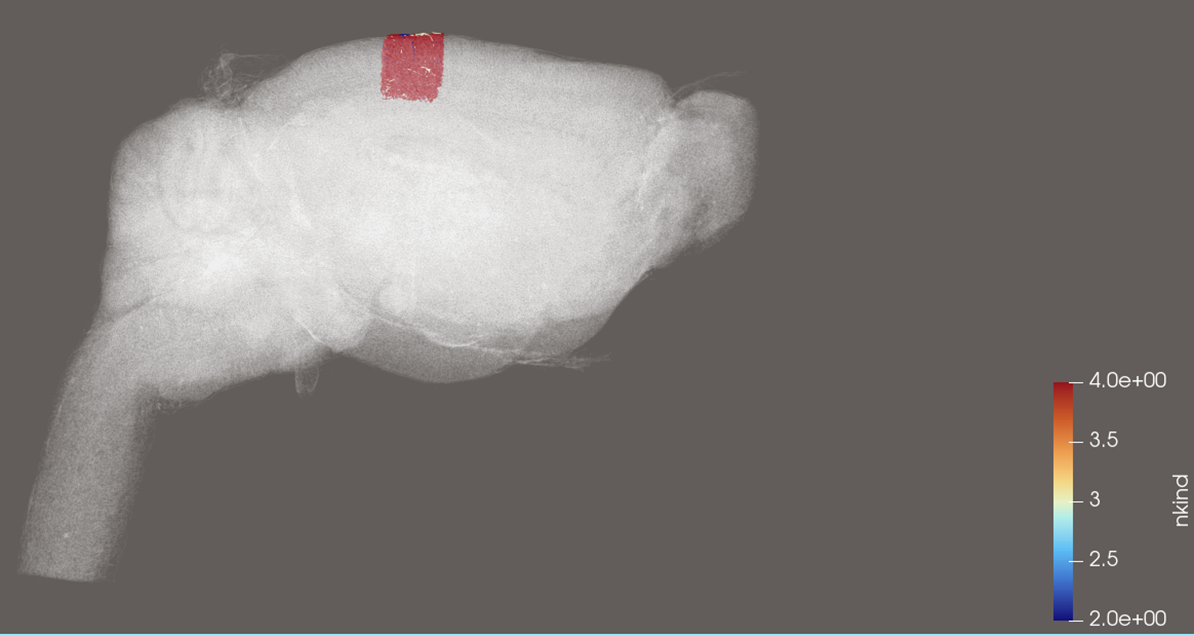